In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from datetime import datetime,timedelta
from sklearn.preprocessing import MinMaxScaler

In [2]:
# plots setup
sns.set_palette([
  "#231651", 
  "#4DCCBD", 
  "#2374AB", 
  "#FF8484", 
  "#1A0F3D", 
  "#6B52AB", 
  "#9BA0FC", 
  "#1B4F72", 
  "#6CB4EE", 
  "#1D8374", 
  "#A1E8D9", 
  "#F4A261", 
  "#E76F51", 
  "#FFB3B3", 
  "#E9D8A6", 
  "#264653"
])
sns.set_context(context="paper", font_scale=1)

mpl.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "font.serif": "Computer Modern Roman",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "font.size": 22,
    }
)
use_pgf = True
plt.rcParams["text.usetex"] = True
hatches=['x',"o","/","\\"]

In [3]:
num_days=30 
cell_id=5200 # duomo trento

# parsing data
dfs=[]
for i in range(11,13):
    for j in range(1,31 if i==11 else 32):
        df_temp=pd.read_csv(os.path.join("/mnt","data","sms-call-internet-mi",f"sms-call-internet-mi-2013-{i:02}-{j:02}.txt"),sep='\t',names=["cell-id","time","code","sms-in","sms-out","call-in","call-out","internet"])
        df_temp.fillna(0,inplace=True)
        dfs.append(df_temp[df_temp["cell-id"]==cell_id])

df=pd.concat(dfs,ignore_index=True)
print(df.head())
print(df.info())


   cell-id           time  code    sms-in   sms-out   call-in  call-out  \
0     5200  1383260400000     0  0.609691  0.000000  0.000000  0.001508   
1     5200  1383260400000    20  0.000000  0.000000  0.000000  0.289950   
2     5200  1383260400000    39  2.012964  0.820358  0.095623  0.321248   
3     5200  1383261000000     0  0.000000  0.031519  0.000000  0.000000   
4     5200  1383261000000    39  0.937411  2.744427  0.784095  0.667102   

    internet  
0   0.000000  
1   0.000000  
2  45.507719  
3   0.000000  
4  41.684094  
<class 'pandas.DataFrame'>
RangeIndex: 28248 entries, 0 to 28247
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   cell-id   28248 non-null  int64  
 1   time      28248 non-null  int64  
 2   code      28248 non-null  int64  
 3   sms-in    28248 non-null  float64
 4   sms-out   28248 non-null  float64
 5   call-in   28248 non-null  float64
 6   call-out  28248 non-null  float64
 7   intern

In [4]:
# grouping by internet traffic
features=["time","sms-in","sms-out","call-in","call-out","internet"]
df_aggr=df.groupby(["time","cell-id"]).sum().reset_index()[features]
df_aggr

,time,sms-in,sms-out,call-in,call-out,internet
0,1383260400000,2.622654,0.820358,0.095623,0.612706,45.507719
1,1383261000000,0.937411,2.775946,0.784095,0.667102,41.684094
2,1383261600000,1.512567,2.244375,0.377152,0.033027,32.155332
3,1383262200000,0.885245,1.583524,0.319741,0.673133,27.975946
4,1383262800000,1.425930,2.451806,0.321248,0.754305,29.653251
...,...,...,...,...,...,...
8779,1388527800000,3.993258,3.807537,0.675744,1.170771,66.776659
8780,1388528400000,3.596833,4.615171,0.389030,0.385794,66.971208
8781,1388529000000,5.820529,11.512949,1.074045,0.991366,64.029736
8782,1388529600000,7.512221,1.635097,1.109462,2.149598,63.950344


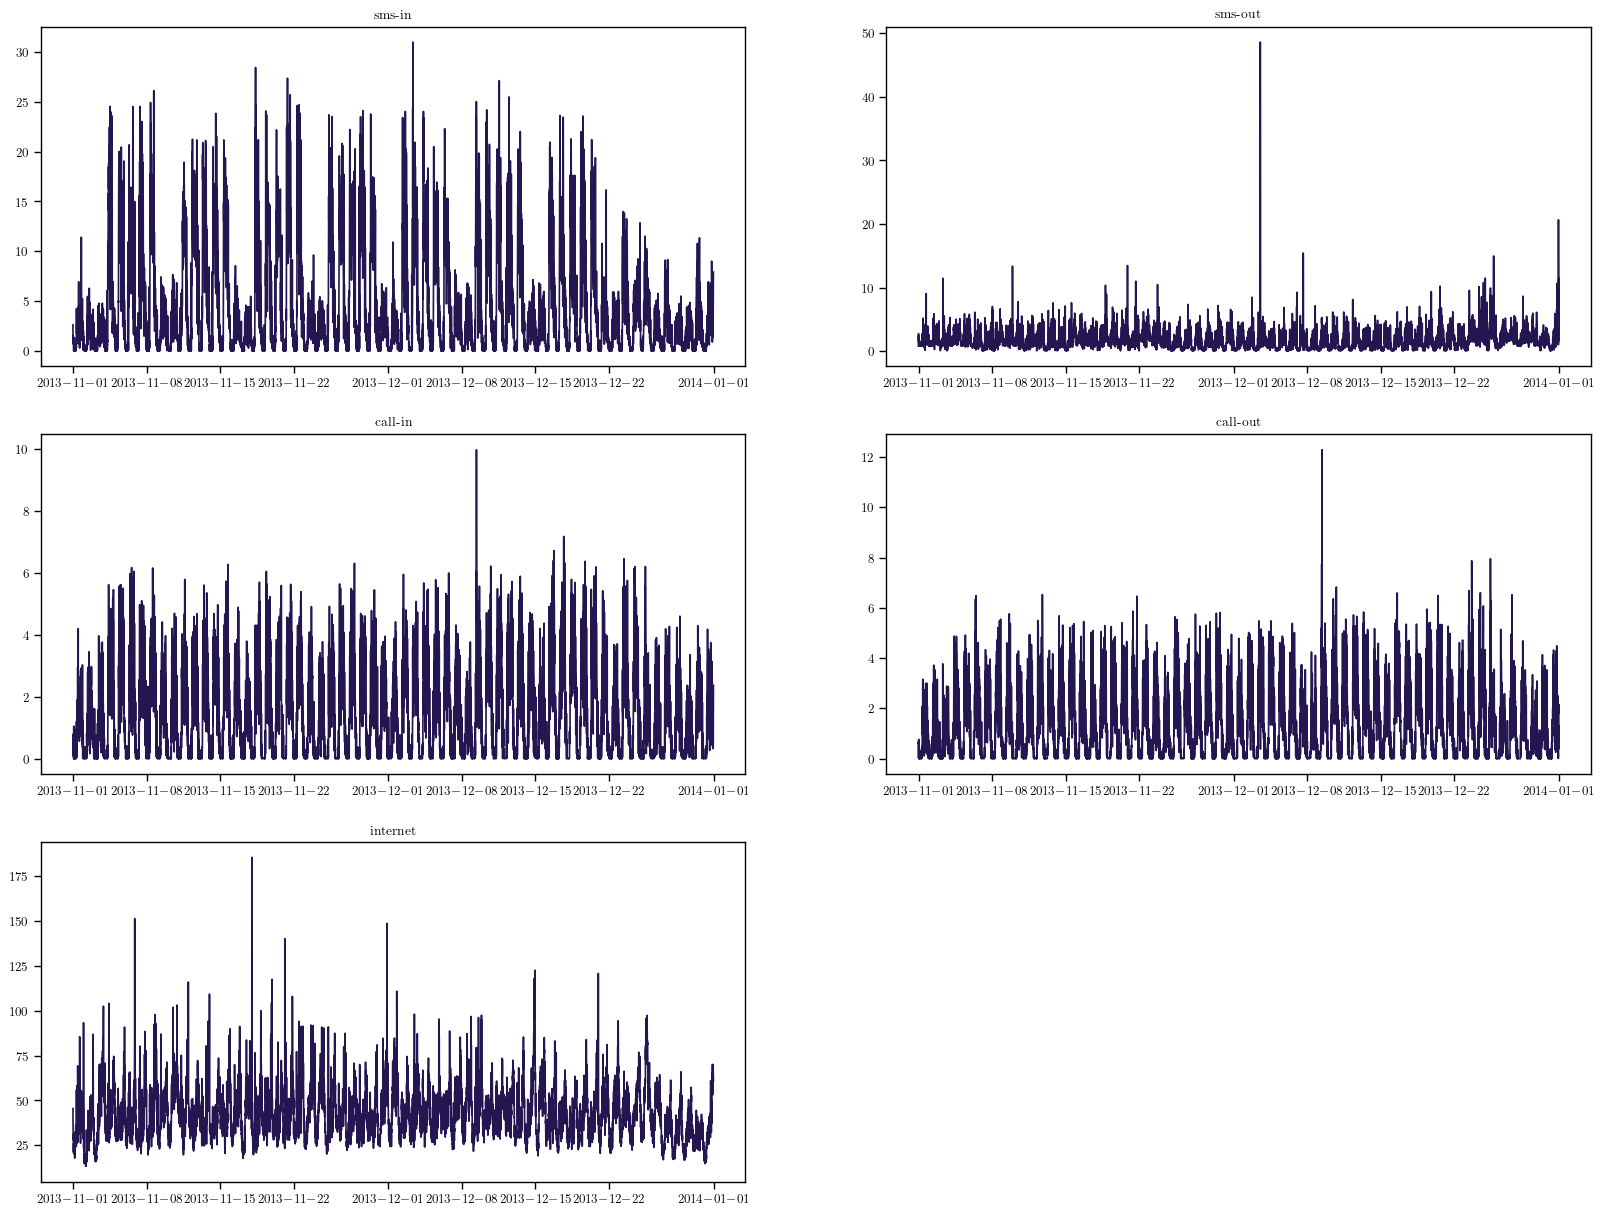

In [5]:
# plotting dataset
plt.figure(figsize=(20,15))
for i,f in enumerate(features[1:]):
    plt.subplot(3,2,i+1)
    plt.title(f)
    plt.plot(pd.to_datetime(df_aggr["time"],unit="ms"),df_aggr[f],color='C0')
plt.show()

In [6]:
df_aggr.to_csv(os.path.join("clean-data",f"traffic-aggr-{cell_id}.csv"))